# 05 - All sources side by side, and a verdict on the previous work

The first four notebooks examined each source on its own. This one puts the six sources in one table
to answer two questions that only make sense together:

1. **How different are the sources?** The project pools them for self-supervised pretraining, so
   differences in population, filtering and scale determine what a pretrained model learns.
2. **Is the previous work correct?** A scorecard of every check across the notebooks, with a
   prioritized list of what to fix.

All numbers come from the cached per-record summaries built by `eda/` from the raw files (about
282,000 recordings).

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from eda.cross import combined_summary, source_fingerprint
from eda.processed import UNION_DIR

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

table = combined_summary()
ORDER = ["ptbxl", "mimic", "georgia", "cpsc_2018", "cpsc_2018_extra", "chapman_shaoxing", "code15"]

## 1. One table for all sources

In [3]:
overview = table.groupby("source").agg(
    records=("std", "size"),
    median_duration_s=("duration_s", "median"),
    median_age=("age", "median"),
    male_share=("male", "mean"),
    signal_std=("std", "median"),
    low_frequency_power=("baseline_fraction", "median"),
    high_frequency_power=("high_frequency_fraction", "median"),
    heart_rate=("heart_rate", "median"),
).loc[ORDER]
overview.loc["mimic", ["median_age", "male_share"]] = np.nan
display(overview.round(3))
problems = table.assign(
    nan=table["nan_leads"] > 0, constant_lead=table["constant_leads"] > 0,
    over_10_units=table["large_leads"] > 0, flat_1s=table["flat_leads"] > 0,
).groupby("source")[["nan", "constant_lead", "flat_1s", "over_10_units"]].mean().loc[ORDER]
display((problems * 100).round(2).rename(columns=lambda name: f"% {name}"))

,records,median_duration_s,median_age,male_share,signal_std,low_frequency_power,high_frequency_power,heart_rate
source,,,,,,,,
ptbxl,21799,10.000,61.0,0.521,0.152,0.020,0.007,71.259
mimic,200000,10.000,NaN,NaN,0.133,0.008,0.011,74.627
georgia,10344,10.000,62.0,0.537,0.143,0.024,0.008,75.282
cpsc_2018,6877,12.000,64.0,0.538,0.149,0.007,0.006,76.923
cpsc_2018_extra,3453,12.000,65.0,0.534,0.144,0.006,0.005,76.628
chapman_shaoxing,10247,10.000,62.0,0.559,0.151,0.023,0.012,73.529
code15,343809,7.335,54.0,0.403,0.316,0.023,0.001,71.006


,% nan,% constant_lead,% flat_1s,% over_10_units
source,,,,
ptbxl,0.00,0.00,0.01,0.22
mimic,1.31,0.24,0.50,0.25
georgia,0.06,0.09,0.12,0.17
cpsc_2018,0.00,0.26,0.86,1.44
cpsc_2018_extra,0.00,0.23,0.87,1.59
chapman_shaoxing,0.00,0.15,0.17,0.21
code15,0.00,0.31,1.60,11.65


**Finding.** Five sources agree closely in amplitude (median signal standard deviation 0.13-0.15 mV),
which confirms their mV units against one another. **CODE-15 is the outlier at about 0.32**, the scale
issue from notebook 04. Populations differ as expected: MIMIC has no demographics in its waveform
release, and CODE-15 is younger and mostly female. Noise profiles split the sources into groups:
CPSC and CPSC-Extra are heavily filtered, and Chapman and MIMIC carry the most high-frequency
content. Integrity problems are rare everywhere: at most about 1.5% of records per category (MIMIC's
NaN gaps, CPSC's rail artifacts), except large-amplitude values in CODE-15 (12%), which are inflated by
its scale.

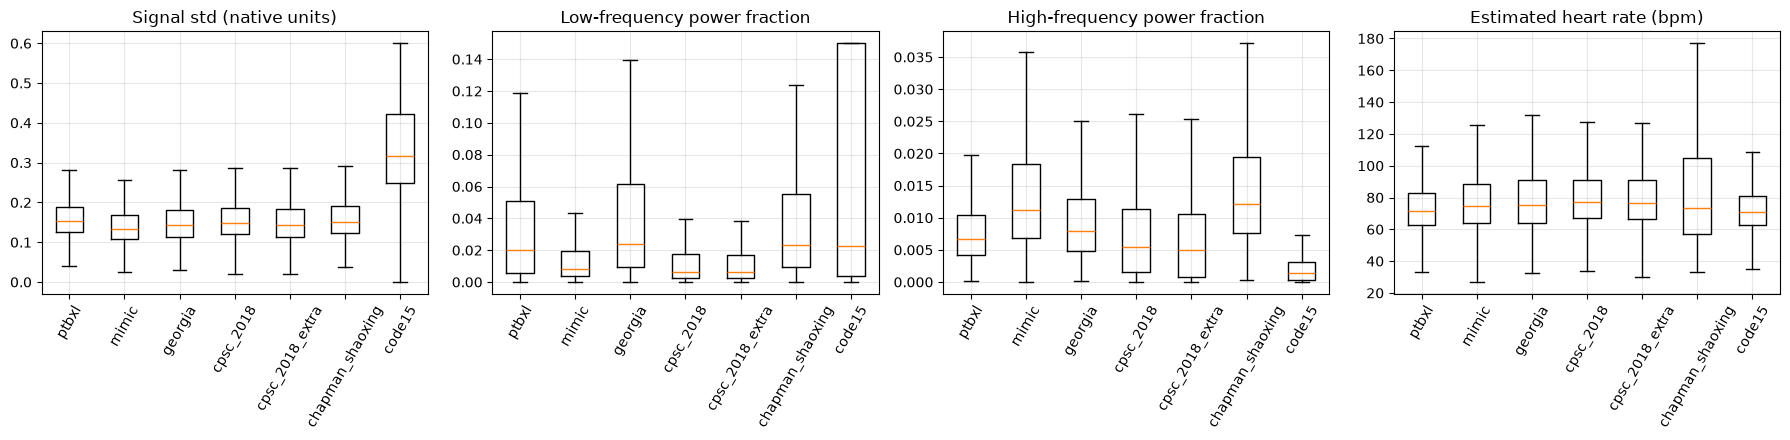

In [4]:
metrics = [("std", "Signal std (native units)", 0.6),
           ("baseline_fraction", "Low-frequency power fraction", 0.15),
           ("high_frequency_fraction", "High-frequency power fraction", 0.05),
           ("heart_rate", "Estimated heart rate (bpm)", 200)]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for axis, (column, title, upper) in zip(axes, metrics, strict=True):
    data = [table.loc[table["source"] == source, column].dropna().clip(upper=upper) for source in ORDER]
    axis.boxplot(data, tick_labels=ORDER, showfliers=False)
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

## 2. Can a model tell the sources apart without looking at the heart?

If the source can be predicted from amplitude and noise statistics alone, then any model can pick up
the source, and any label correlated with the source becomes a shortcut. We train a small classifier
on six non-cardiac features (signal spread, low- and high-frequency power, 50 and 60 Hz power, and
exact-zero fraction) using an equal number of records per source.

Balanced accuracy: 0.65 (chance: 0.14)


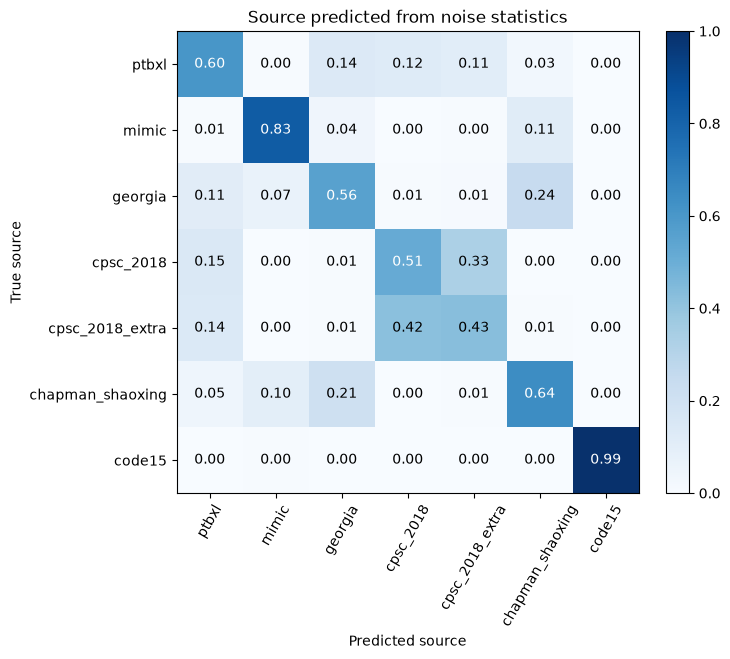

,ptbxl,mimic,georgia,cpsc_2018,cpsc_2018_extra,chapman_shaoxing,code15
ptbxl,0.60,0.00,0.14,0.12,0.11,0.03,0.00
mimic,0.01,0.83,0.04,0.00,0.00,0.11,0.00
georgia,0.11,0.07,0.56,0.01,0.01,0.24,0.00
cpsc_2018,0.15,0.00,0.01,0.51,0.33,0.00,0.00
cpsc_2018_extra,0.14,0.00,0.01,0.42,0.43,0.01,0.00
chapman_shaoxing,0.05,0.10,0.21,0.00,0.01,0.64,0.00
code15,0.00,0.00,0.00,0.00,0.00,0.00,0.99


In [5]:
accuracy, confusion = source_fingerprint(table, per_source=3000)
print(f"Balanced accuracy: {accuracy:.2f} (chance: {1 / len(ORDER):.2f})")
confusion = confusion.loc[ORDER, ORDER]
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(confusion, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(ORDER)), ORDER, rotation=60)
ax.set_yticks(range(len(ORDER)), ORDER)
for row in range(len(ORDER)):
    for column in range(len(ORDER)):
        value = confusion.iloc[row, column]
        color = "white" if value > 0.5 else "black"
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", color=color)
ax.set(xlabel="Predicted source", ylabel="True source", title="Source predicted from noise statistics")
ax.grid(False)
fig.colorbar(image, ax=ax, fraction=0.046)
plt.show()
display(confusion.round(2))

**Finding: every source leaves a fingerprint.** With no cardiac information, the classifier names the
source correctly about 65% of the time, against 14% by chance. CODE-15 is recognized almost perfectly
(99%, its scale), and MIMIC about 80% of the time (its filtering). The confusions are informative: CPSC 2018 and
CPSC-Extra are mistaken for each other (same hospital and pipeline), and Georgia and Chapman overlap.

For self-supervised pretraining this is expected and mostly harmless. It becomes a problem when a
label correlates with the source. Notebook 01 showed that inside PTB-XL the same thing happens with
devices, which do correlate with the label. Any future supervised use of more than one source needs
per-source evaluation.

## 3. What the project actually pools

In [6]:
union = pd.read_csv(UNION_DIR / "train_manifest.csv", usecols=["source"])
composition = pd.DataFrame({
    "frozen pool records": pd.Series({"ptbxl": 17418, "mimic": 39457}),
    "union records": union["source"].value_counts(),
}).fillna(0).astype(int)
for name in ("frozen pool", "union"):
    composition[f"{name} share"] = composition[f"{name} records"] / composition[f"{name} records"].sum()
display(composition.round(3))

,frozen pool records,union records,frozen pool share,union share
cpsc_2018,0,6581,0.000,0.086
cpsc_2018_extra,0,3021,0.000,0.039
georgia,0,10187,0.000,0.133
mimic,39457,39392,0.694,0.514
ptbxl,17418,17417,0.306,0.227


**Finding.** The frozen pool that most experiments used is 69% MIMIC and 31% PTB-XL, so pretrained
representations are dominated by MIMIC's filtering regime and population. The union dataset adds
three Challenge sources (26% of it) with two further filtering regimes. Neither contains CODE-15 or
Chapman. Whether the extra sources help is an empirical question the project has started to test;
this EDA only says they are measurably different, and that they are clean enough to use.

## 4. Scorecard of the previous work

Every check in notebooks 01-05, grouped by verdict. **Correct** means we reproduced it independently
from the raw data.

| Area | Check | Verdict |
| --- | --- | --- |
| PTB-XL | Label rule implemented as documented; all 8 manifests reproduced exactly | Correct |
| PTB-XL | Official folds used; human-validated folds 9/10 for evaluation | Correct |
| PTB-XL | No patient shared across train, validation and test; label subset nested | Correct |
| PTB-XL | Evaluation drops 14% of held-out records (borderline and conflicting cases) | **Issue, high** |
| PTB-XL | No age-only baseline reported (age alone: AUROC 0.79) | **Issue, high** |
| PTB-XL | Device shifts between folds and correlates with label and filtering | **Issue, medium** |
| PTB-XL | Label rule limits negatives to 43-117 bpm | **Issue, medium** |
| Arrays | 100 Hz cache and 500 Hz union match raw files exactly | Correct |
| Arrays | 250 Hz frozen pool has a filter artifact at the 5 s join (up to 0.3 mV) | **Issue, medium** |
| MIMIC | Random whole-patient selection; 40k subset is an exact prefix | Correct |
| MIMIC | Swapped aVF/aVL header order handled by name | Correct |
| MIMIC | All NaN records excluded, counts match exactly | Correct |
| MIMIC | Constant-lead records kept in manifests and in the frozen pool (65) | **Issue, low** |
| MIMIC | One cart (13%) is a distinct sub-population | Note |
| Challenge | Windows match raw; every exclusion reproduced (duplicates, short, NaN, rail, constant) | Correct |
| Challenge | Exact-value rail rule misses 29 near-rail windows | **Issue, low** |
| Challenge | Chapman excluded, although clean | Note |
| CODE-15 | Not used while units and duration were unresolved | Correct |
| CODE-15 | All 18 parts complete in a verified export archive; exam table matches one to one | Correct |
| CODE-15 | Waveforms moved to the export archive without updating the receipt or docs | **Issue, low** |
| CODE-15 | Amplitudes about 2x mV; two acquisition pipelines by length | Note, resolves open questions |
| Process | Earlier waveform EDA sampled 64 records per source | Note, now covered in full |

**Overall verdict.** The data engineering is careful and largely correct. Files are read correctly,
leads are ordered by name, patients never leak across splits, and exclusions are reproducible. The
problems are not in the code but in **scientific choices that make results look better or less
general than they are**: an evaluation set without its hard cases, no demographic baseline, an
unexamined device shortcut, and a label rule that narrows what "normal" means. Those are the issues to
fix before trusting the reported AUROCs.

## 5. Recommended next steps, in order

1. **Re-evaluate on the full folds 9 and 10** with the standard PTB-XL superclass label, and report it
   next to the current numbers. Cheap, and it changes how every result is read.
2. **Add metadata baselines** (age, age + sex) and **stratify** results by age band and by device.
3. **Check the device shortcut**: test whether model scores predict device, and report per-device AUROC.
4. **Rebuild the 250 Hz pool** with whole-record resampling, and apply the constant-lead and
   near-rail rules to every manifest, before new pretraining runs.
5. **Update the CODE-15 receipt and docs** to point to the export archive, and confirm the scale
   factor before any use.
6. Consider **adding Chapman** (after deduplication) and **CODE-15** (after rescaling and cropping) to
   pretraining, as separate, recorded data-scaling experiments.